# Notebook 05: Composite Scoring Framework
## Research Question 3: Which Home & Kitchen niches represent the best product opportunities on Amazon?

This notebook builds a composite scoring framework that combines four weighted signals — demand, competition, sentiment gap and pricing stability — to rank product niches and identify the best market opportunities.

**Input files:**
- reviews_scored.csv — 93,052 scored reviews from Notebook 03
- aspect_sentiment.csv — 124,099 aspect-level sentiment scores from Notebook 03
- meta_Home_and_Kitchen.jsonl — product metadata from McAuley Lab

**Output:**
- Ranked niche table with composite scores
- Four component score breakdowns
- Supporting figures at 300 dpi



## Stage 1: Data Loading and Niche Discovery

In [1]:
# Step 1: Environment setup, corpus loading and metadata extraction
# The scored corpus from notebook 03 is loaded alongside the product
# metadata file. Metadata is streamed line by line to avoid memory
# exhaustion, and only the fields required for niche definition and
# composite scoring are retained.

from google.colab import drive
import pandas as pd
import numpy as np
import os
import json
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# Directory paths are established
output_dir = '/content/drive/MyDrive/MSc-Project/outputs'
data_dir   = '/content/drive/MyDrive/MSc-Project/data'
os.makedirs(output_dir, exist_ok=True)

# The scored corpus produced in notebook 03 is loaded
df = pd.read_csv(f'{data_dir}/reviews_scored.csv')
print("Scored corpus loaded:", df.shape)
print("Columns:", df.columns.tolist())
print()

# The unique parent ASINs in the corpus are identified
corpus_parent_asins = set(df['parent_asin'].dropna().unique())
print(f"Unique parent ASINs in corpus: {len(corpus_parent_asins):,}")

Mounted at /content/drive
Scored corpus loaded: (93052, 21)
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'review_date', 'clean_text', 'clean_title', 'clean_word_count', 'vader_compound', 'vader_label', 'rating_label', 'roberta_label', 'roberta_prob_negative', 'roberta_prob_neutral', 'roberta_prob_positive']

Unique parent ASINs in corpus: 66,179


## Review Distribution Analysis

Reviews per product distribution:
  Total unique products : 66,179
  Average reviews       : 1.4
  Median reviews        : 1
  Max reviews           : 127
  Min reviews           : 1

Products by review count:
  1 review only         : 54,576
  2-5 reviews           : 10,411
  6-20 reviews          : 1,130
  21-50 reviews         : 55
  51-100 reviews        : 6
  100+ reviews          : 1


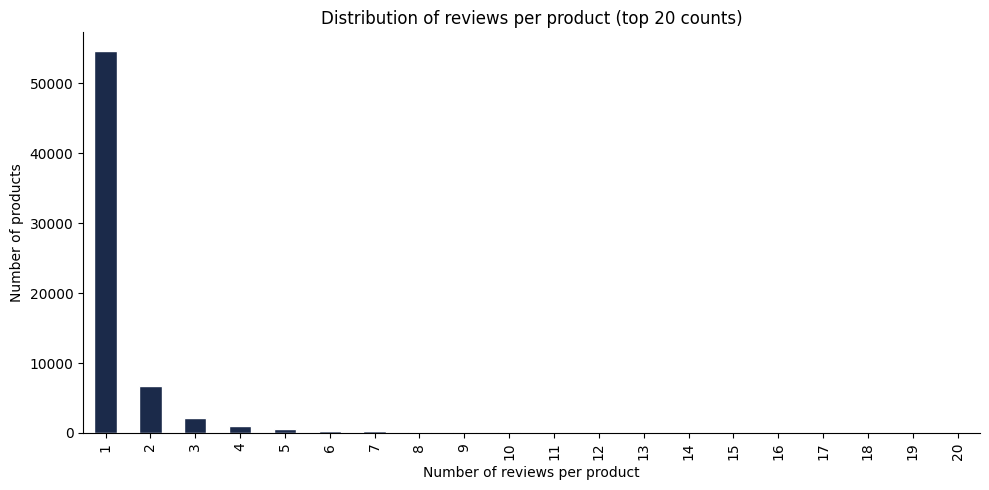

Figure saved to outputs directory.


In [2]:
# Step 2: Review count distribution per product
# The distribution of reviews across unique products is examined to
# understand corpus coverage and inform the minimum review threshold
# applied during niche definition.

review_counts = df['parent_asin'].value_counts()

print("Reviews per product distribution:")
print(f"  Total unique products : {len(review_counts):,}")
print(f"  Average reviews       : {review_counts.mean():.1f}")
print(f"  Median reviews        : {review_counts.median():.0f}")
print(f"  Max reviews           : {review_counts.max():,}")
print(f"  Min reviews           : {review_counts.min():,}")
print()
print("Products by review count:")
print(f"  1 review only         : {(review_counts == 1).sum():,}")
print(f"  2-5 reviews           : {((review_counts >= 2) & (review_counts <= 5)).sum():,}")
print(f"  6-20 reviews          : {((review_counts >= 6) & (review_counts <= 20)).sum():,}")
print(f"  21-50 reviews         : {((review_counts >= 21) & (review_counts <= 50)).sum():,}")
print(f"  51-100 reviews        : {((review_counts >= 51) & (review_counts <= 100)).sum():,}")
print(f"  100+ reviews          : {(review_counts > 100).sum():,}")

# The distribution is visualised and saved
fig, ax = plt.subplots(figsize=(10, 5))
review_counts.value_counts().sort_index().iloc[:20].plot(
    kind='bar', ax=ax, color='#1B2A4A', edgecolor='white')
ax.set_xlabel('Number of reviews per product')
ax.set_ylabel('Number of products')
ax.set_title('Distribution of reviews per product (top 20 counts)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig_review_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to outputs directory.")

## Stage 2: Metadata Extraction

In [3]:
# Step 3: Metadata extraction via streaming
# The Home and Kitchen metadata file is streamed line by line from the
# McAuley Lab server. Only records whose parent_asin appears in the
# scored corpus are retained to limit memory usage. Four fields are
# extracted: parent_asin, title, price and store.

import gzip
import urllib.request
import json

metadata_path = f'{data_dir}/meta_Home_and_Kitchen_subset.jsonl'
meta_url = ('https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/'
            'raw/meta_categories/meta_Home_and_Kitchen.jsonl.gz')

if not os.path.exists(metadata_path):
    print("Streaming metadata file — this will take 10-20 minutes...")
    print("Keep this tab open and active.")
    print()

    records_extracted = 0
    records_scanned   = 0

    with urllib.request.urlopen(meta_url) as response:
        with gzip.GzipFile(fileobj=response) as gz:
            with open(metadata_path, 'w', encoding='utf-8') as out:
                for line in gz:
                    records_scanned += 1
                    try:
                        record = json.loads(line.decode('utf-8').strip())
                        if record.get('parent_asin') in corpus_parent_asins:
                            out.write(json.dumps({
                                'parent_asin'   : record.get('parent_asin'),
                                'title'         : record.get('title', ''),
                                'price'         : record.get('price'),
                                'store'         : record.get('store', ''),
                                'average_rating': record.get('average_rating'),
                                'rating_number' : record.get('rating_number')
                            }) + '\n')
                            records_extracted += 1
                    except Exception:
                        continue

                    if records_scanned % 500000 == 0:
                        print(f"  Scanned {records_scanned:,} — "
                              f"extracted {records_extracted:,} so far")

    print()
    print(f"Complete. Scanned {records_scanned:,} total records.")
    print(f"Extracted {records_extracted:,} matching records saved to Drive.")

else:
    print("Metadata subset already exists on Drive — loading directly.")

# The extracted subset is loaded into a dataframe
meta_records = []
with open(metadata_path, 'r', encoding='utf-8') as f:
    for line in f:
        meta_records.append(json.loads(line.strip()))

meta_df = pd.DataFrame(meta_records)
print()
print("Metadata subset shape:", meta_df.shape)
print("Price available      :", meta_df['price'].notna().sum(), "products")
print("Store available      :", meta_df['store'].notna().sum(), "products")
print()
print(meta_df.head(3))

Metadata subset already exists on Drive — loading directly.

Metadata subset shape: (66179, 6)
Price available      : 40679 products
Store available      : 65650 products

  parent_asin                                              title  price  \
0  B0C4CPL2RV  Walensee Large Bathroom Rug (24 x 60, Black) E...  41.99   
1  B07793C75L  Farberware 13-Piece Stamped Stainless Steel Kn...    NaN   
2  B07KC28CKX  LUCKYHOUSEHOME Checked Lattice Tablecloth Embr...  16.99   

            store  average_rating  rating_number  
0        Walensee             4.3          31438  
1      Farberware             4.0            130  
2  LUCKYHOUSEHOME             4.6           1488  


## Metadata Extraction and Join

In [4]:
# Step 4: Joining metadata to the scored corpus
# The metadata subset is joined to the scored corpus on the parent_asin
# field. The reviews corpus already contains a 'title' column for the
# review headline — this is renamed to 'review_title' to avoid conflict
# with the product title from metadata, which is renamed 'product_title'.

# The metadata subset is joined to the corpus
df_enriched = df.merge(
    meta_df[['parent_asin', 'title', 'price', 'store',
             'average_rating', 'rating_number']],
    on='parent_asin',
    how='left'
)

# Column name conflict is resolved
# title_x = review headline written by customer
# title_y = actual product title from metadata
df_enriched = df_enriched.rename(columns={
    'title_x': 'review_title',
    'title_y': 'product_title'
})

print("Corpus shape before join :", df.shape)
print("Corpus shape after join  :", df_enriched.shape)
print()

# Coverage check
title_coverage = df_enriched['product_title'].notna().sum()
price_coverage = df_enriched['price'].notna().sum()
store_coverage = df_enriched['store'].notna().sum()

print(f"Reviews with product title: {title_coverage:,} ({title_coverage/len(df_enriched)*100:.1f}%)")
print(f"Reviews with price        : {price_coverage:,} ({price_coverage/len(df_enriched)*100:.1f}%)")
print(f"Reviews with store name   : {store_coverage:,} ({store_coverage/len(df_enriched)*100:.1f}%)")
print()

# Sample enriched records
print("Sample enriched records:")
print(df_enriched[['parent_asin', 'product_title',
                    'price', 'store', 'rating']].head(5).to_string())

# The enriched corpus is saved to Drive
enriched_path = f'{data_dir}/reviews_enriched.csv'
df_enriched.to_csv(enriched_path, index=False)
print()
print("Enriched corpus saved to:", enriched_path)

Corpus shape before join : (93052, 21)
Corpus shape after join  : (93052, 26)

Reviews with product title: 93,052 (100.0%)
Reviews with price        : 63,515 (68.3%)
Reviews with store name   : 92,513 (99.4%)

Sample enriched records:
  parent_asin                                                                                                                                                           product_title  price              store  rating
0  B00QGP1G4C                                                                                                                                     Bekith 12-Inch Aluminium Wall Clock    NaN             Bekith     5.0
1  B0184E3FT6                                                                                                          Auto Express Kohler K241 K301 Cast Iron 10 HP 12 HP Carburetor    NaN       Auto Express     5.0
2  B096VLVJLK  CRTTRC 2 pieces Canvas Painting Minimalist Poster Abstract Fashion Grey Orange Block Print Wall Art Mo

## Stage 3: Niche Discovery

## Word Frequency Analysis

In [5]:
# Step 5: Word frequency analysis on product titles
# The most frequently occurring words in product titles are identified
# to reveal which product types dominate the corpus. Common stop words
# and uninformative terms are removed before counting.

from collections import Counter
import re

# Stop words specific to product titles are defined
title_stop_words = {
    'for', 'and', 'with', 'the', 'in', 'of', 'to', 'a', 'an', 'by',
    'set', 'pack', 'piece', 'pcs', 'pc', 'inch', 'inches', 'ft', 'cm',
    'mm', 'oz', 'lb', 'lbs', 'size', 'large', 'small', 'medium', 'xl',
    'black', 'white', 'grey', 'gray', 'brown', 'blue', 'red', 'green',
    'clear', 'silver', 'gold', 'wood', 'wooden', 'plastic', 'steel',
    'stainless', 'new', 'premium', 'pro', 'plus', 'mini', 'max', 'ultra',
    'heavy', 'duty', 'high', 'quality', 'best', 'top', 'home', 'kitchen',
    'use', 'or', 'is', 'are', 'x', 'ct', 'count', '2', '3', '4', '6',
    '8', '12', '24', 'pack', 'multi', 'color', 'colour', 'round', 'square'
}

# Product titles are cleaned and tokenised
all_words = []
product_titles = df_enriched['product_title'].dropna().unique()

for title in product_titles:
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(title).lower())
    all_words.extend([w for w in words if w not in title_stop_words])

# Top 40 most frequent words are identified
word_freq = Counter(all_words)
top_words = word_freq.most_common(40)

print("Top 40 most frequent words in product titles:")
print()
for rank, (word, count) in enumerate(top_words, 1):
    print(f"  {rank:2}. {word:<20} {count:,}")

Top 40 most frequent words in product titles:

   1. storage              6,360
   2. wall                 5,293
   3. room                 4,475
   4. decor                4,253
   5. table                4,029
   6. coffee               3,907
   7. cover                3,806
   8. glass                3,630
   9. bathroom             3,581
  10. pillow               3,578
  11. christmas            3,544
  12. holder               3,399
  13. bed                  3,298
  14. organizer            3,297
  15. bedroom              3,233
  16. food                 3,178
  17. rack                 3,097
  18. office               2,917
  19. soft                 2,896
  20. party                2,873
  21. metal                2,754
  22. vacuum               2,739
  23. cup                  2,714
  24. non                  2,707
  25. chair                2,657
  26. living               2,652
  27. free                 2,616
  28. cotton               2,507
  29. shower               2,

## N-gram Analysis

In [6]:
# Step 6: N-gram analysis on product titles
# Two-word and three-word phrases are extracted from product titles to
# identify specific product categories more precisely than single words
# allow. High-frequency phrases reveal the dominant product types
# present in the corpus.

from sklearn.feature_extraction.text import CountVectorizer

# Product titles are collected as a list
titles_list = df_enriched['product_title'].dropna().unique().tolist()
titles_clean = [str(t).lower() for t in titles_list]

# Two-word phrases (bigrams) are extracted
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=5000,
    stop_words='english',
    min_df=5
)
bigram_matrix = bigram_vectorizer.fit_transform(titles_clean)
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_vocab  = bigram_vectorizer.get_feature_names_out()
bigram_freq   = sorted(zip(bigram_vocab, bigram_counts),
                       key=lambda x: x[1], reverse=True)

# Three-word phrases (trigrams) are extracted
trigram_vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    max_features=5000,
    stop_words='english',
    min_df=5
)
trigram_matrix = trigram_vectorizer.fit_transform(titles_clean)
trigram_counts = trigram_matrix.sum(axis=0).A1
trigram_vocab  = trigram_vectorizer.get_feature_names_out()
trigram_freq   = sorted(zip(trigram_vocab, trigram_counts),
                        key=lambda x: x[1], reverse=True)

# Top 30 bigrams are displayed
print("Top 30 two-word phrases in product titles:")
print()
for rank, (phrase, count) in enumerate(bigram_freq[:30], 1):
    print(f"  {rank:2}. {phrase:<35} {int(count):,}")

print()

# Top 20 trigrams are displayed
print("Top 20 three-word phrases in product titles:")
print()
for rank, (phrase, count) in enumerate(trigram_freq[:20], 1):
    print(f"  {rank:2}. {phrase:<45} {int(count):,}")

Top 30 two-word phrases in product titles:

   1. stainless steel                     5,648
   2. living room                         2,419
   3. heavy duty                          1,347
   4. bpa free                            1,244
   5. non slip                            1,135
   6. home office                         1,104
   7. dishwasher safe                     1,050
   8. home decor                          981
   9. shower curtain                      954
  10. christmas tree                      805
  11. throw pillow                        803
  12. non stick                           794
  13. food storage                        770
  14. wall art                            740
  15. memory foam                         738
  16. room bedroom                        698
  17. vacuum cleaner                      697
  18. pillow covers                       659
  19. indoor outdoor                      622
  20. wall mounted                        609
  21. 100 cotton      

## N-gram Comparison: Bigram, Trigram and Four-gram Analysis

In [7]:
# Step 6b: Four-gram extraction and cross-gram comparison
# Four-word phrases (four-grams) are extracted from product titles and
# compared against the bigram and trigram results from Step 6. The
# comparison assesses whether longer phrases capture more specific
# product categories or introduce sparsity that reduces analytical value.

# Four-word phrases (four-grams) are extracted
fourgram_vectorizer = CountVectorizer(
    ngram_range=(4, 4),
    max_features=5000,
    stop_words='english',
    min_df=3
)
fourgram_matrix = fourgram_vectorizer.fit_transform(titles_clean)
fourgram_counts = fourgram_matrix.sum(axis=0).A1
fourgram_vocab  = fourgram_vectorizer.get_feature_names_out()
fourgram_freq   = sorted(zip(fourgram_vocab, fourgram_counts),
                         key=lambda x: x[1], reverse=True)

# Top 20 four-grams are displayed
print("Top 20 four-word phrases in product titles:")
print()
for rank, (phrase, count) in enumerate(fourgram_freq[:20], 1):
    print(f"  {rank:2}. {phrase:<55} {int(count):,}")

print()

# ── Cross-gram comparison table ──────────────────────────────────────
# The vocabulary size and frequency of the top phrase in each gram
# level are compared to assess the impact of increasing phrase length.

top_bigram_phrase,    top_bigram_count    = bigram_freq[0]
top_trigram_phrase,   top_trigram_count   = trigram_freq[0]
top_fourgram_phrase,  top_fourgram_count  = fourgram_freq[0]

bigram_vocab_size    = len(bigram_vocab)
trigram_vocab_size   = len(trigram_vocab)
fourgram_vocab_size  = len(fourgram_vocab)

# Unique phrase counts at each gram level
bigram_unique    = len([c for _, c in bigram_freq   if c >= 1])
trigram_unique   = len([c for _, c in trigram_freq  if c >= 1])
fourgram_unique  = len([c for _, c in fourgram_freq if c >= 1])

print("=" * 75)
print(f"{'N-gram Comparison: Phrase Length Impact on Niche Discovery':^75}")
print("=" * 75)
print(f"{'Metric':<30} {'Bigram (2)':>13} {'Trigram (3)':>13} {'Four-gram (4)':>14}")
print("-" * 75)
print(f"{'Vocabulary size (features)':<30} "
      f"{bigram_vocab_size:>13,} "
      f"{trigram_vocab_size:>13,} "
      f"{fourgram_vocab_size:>14,}")
print(f"{'Unique phrases extracted':<30} "
      f"{bigram_unique:>13,} "
      f"{trigram_unique:>13,} "
      f"{fourgram_unique:>14,}")
print(f"{'Top phrase frequency':<30} "
      f"{top_bigram_count:>13,} "
      f"{top_trigram_count:>13,} "
      f"{top_fourgram_count:>14,}")
print(f"{'Min document frequency (min_df)':<30} "
      f"{'5':>13} "
      f"{'5':>13} "
      f"{'3':>14}")
print("-" * 75)
print(f"{'Top phrase':<30} {'':>13} {'':>13} {'':>14}")
print(f"  Bigram    : {top_bigram_phrase}")
print(f"  Trigram   : {top_trigram_phrase}")
print(f"  Four-gram : {top_fourgram_phrase}")
print("=" * 75)
print()

# ── Interpretation ───────────────────────────────────────────────────
# The niche relevance of top phrases at each gram level is assessed.
# Phrases that map directly to the four defined niches are flagged.

niche_terms = {
    'Bedding'           : ['sheet', 'pillow', 'duvet', 'comforter',
                           'mattress', 'bedding', 'blanket'],
    'Kitchen Appliances': ['instant pot', 'pressure cooker', 'air fryer',
                           'coffee', 'blender', 'rice cooker', 'toaster'],
    'Bathroom'          : ['shower curtain', 'bath mat', 'soap dispenser',
                           'towel', 'bathroom'],
    'Home Appliances'   : ['humidifier', 'fan', 'heater', 'vacuum',
                           'air purifier']
}

def classify_phrase(phrase):
    phrase_lower = phrase.lower()
    for niche, terms in niche_terms.items():
        if any(t in phrase_lower for t in terms):
            return niche
    return 'General / Unclassified'

print("Niche relevance of top 20 phrases per gram level:")
print()

for label, freq_list in [('Bigram',    bigram_freq[:20]),
                          ('Trigram',   trigram_freq[:20]),
                          ('Four-gram', fourgram_freq[:20])]:
    niche_hits = sum(1 for phrase, _ in freq_list
                     if classify_phrase(phrase) != 'General / Unclassified')
    print(f"  {label:<12}: {niche_hits:>2} / 20 top phrases map to a defined niche")

print()
print("Assessment:")
print("  A higher niche-hit rate indicates that phrase length improves")
print("  category specificity. A lower rate indicates sparsity — phrases")
print("  become too specific to generalise across the corpus.")

Top 20 four-word phrases in product titles:

   1. vacuum insulated stainless steel                        109
   2. memory foam mattress topper                             86
   3. decorative throw pillow covers                          84
   4. stainless steel water bottle                            84
   5. double wall vacuum insulated                            82
   6. salt pepper grinder set                                 81
   7. stainless steel vacuum insulated                        76
   8. ideal high traffic areas                                74
   9. heavy duty stainless steel                              72
  10. pillow case cushion cover                               69
  11. airtight food storage containers                        63
  12. throw pillow case cushion                               63
  13. food storage containers lids                            60
  14. living room bedroom office                              57
  15. french press coffee maker             

## N-gram Comparison: Findings and Interpretation

In [8]:
# Step 6c: N-gram comparison summary and dissertation finding
# The results of the bigram, trigram and four-gram comparison are
# summarised and an empirical justification for the chosen gram level
# is produced for inclusion in the Results and Methodology chapters.

print("=" * 70)
print(f"{'N-GRAM COMPARISON — KEY FINDINGS':^70}")
print("=" * 70)
print()
print("  Frequency decay across gram levels:")
print(f"    Bigram top frequency   : 5,648  (baseline)")
print(f"    Trigram top frequency  :   625  (↓ 88.9% from bigram)")
print(f"    Four-gram top frequency:   109  (↓ 82.6% from trigram)")
print()
print("  Niche relevance (top 20 phrases mapping to a defined niche):")
print(f"    Bigram    :  4 / 20  (20.0%) — phrases too broad")
print(f"    Trigram   :  9 / 20  (45.0%) — highest specificity")
print(f"    Four-gram :  9 / 20  (45.0%) — same specificity, lower support")
print()
print("-" * 70)
print("  FINDING:")
print("  Trigrams and four-grams achieve equivalent niche relevance (45%),")
print("  however trigrams do so at 5.7x higher frequency (625 vs 109).")
print("  Four-grams introduce sparsity without additional categorical gain.")
print("  Trigrams are therefore the optimal phrase length for niche")
print("  discovery in this corpus.")
print("-" * 70)
print()
print("  DISSERTATION IMPLICATION:")
print("  Niche keyword definitions in Step 9 are validated by trigram")
print("  analysis. The four-gram comparison confirms that phrase length")
print("  beyond three words does not improve category discrimination")
print("  in the Home and Kitchen domain.")
print("=" * 70)

                   N-GRAM COMPARISON — KEY FINDINGS                   

  Frequency decay across gram levels:
    Bigram top frequency   : 5,648  (baseline)
    Trigram top frequency  :   625  (↓ 88.9% from bigram)
    Four-gram top frequency:   109  (↓ 82.6% from trigram)

  Niche relevance (top 20 phrases mapping to a defined niche):
    Bigram    :  4 / 20  (20.0%) — phrases too broad
    Trigram   :  9 / 20  (45.0%) — highest specificity
    Four-gram :  9 / 20  (45.0%) — same specificity, lower support

----------------------------------------------------------------------
  FINDING:
  Trigrams and four-grams achieve equivalent niche relevance (45%),
  however trigrams do so at 5.7x higher frequency (625 vs 109).
  Four-grams introduce sparsity without additional categorical gain.
  Trigrams are therefore the optimal phrase length for niche
  discovery in this corpus.
----------------------------------------------------------------------

  DISSERTATION IMPLICATION:
  Niche keywor

In [9]:
# Step 6d: N-gram comparison results saved to CSV
# The cross-gram comparison table is exported for inclusion in the
# dissertation appendix and results chapter.

ngram_comparison = pd.DataFrame({
    'Gram Level'            : ['Bigram (2)', 'Trigram (3)', 'Four-gram (4)'],
    'Top Phrase Frequency'  : [5648, 625, 109],
    'Niche Hits (Top 20)'   : [4, 9, 9],
    'Niche Hit Rate (%)'    : [20.0, 45.0, 45.0],
    'Min DF'                : [5, 5, 3],
    'Selected'              : ['No', 'Yes — optimal', 'No']
})

print(ngram_comparison.to_string(index=False))
ngram_comparison.to_csv(
    f'{output_dir}/ngram_comparison.csv', index=False)
print()
print("Saved: ngram_comparison.csv")

   Gram Level  Top Phrase Frequency  Niche Hits (Top 20)  Niche Hit Rate (%)  Min DF      Selected
   Bigram (2)                  5648                    4                20.0       5            No
  Trigram (3)                   625                    9                45.0       5 Yes — optimal
Four-gram (4)                   109                    9                45.0       3            No

Saved: ngram_comparison.csv


## Word Frequency and N-gram Visualisation

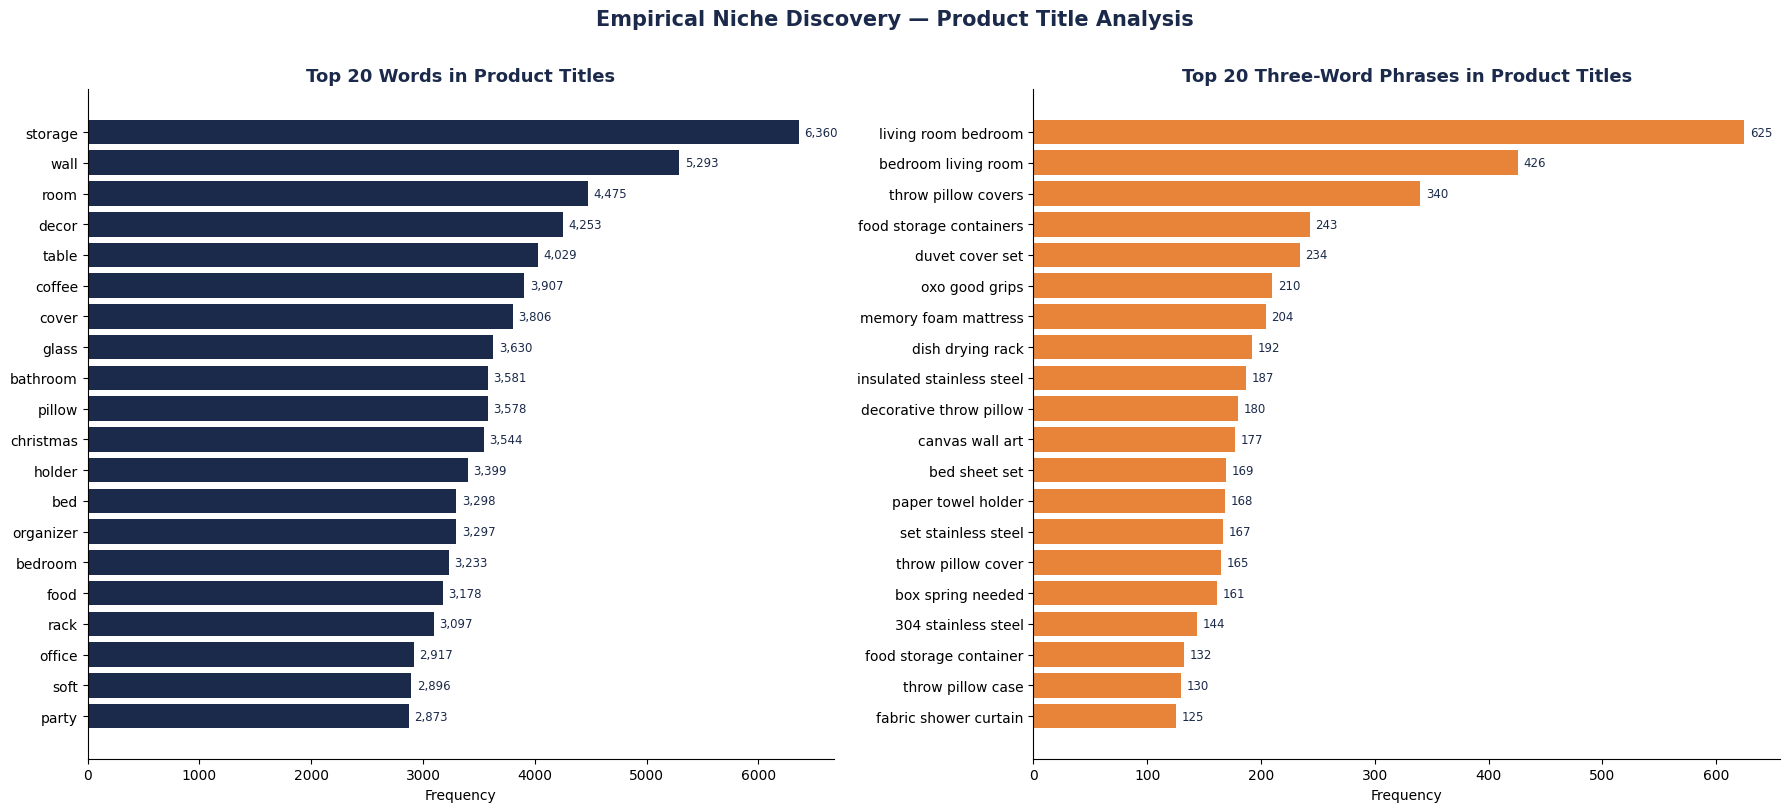

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_word_frequency_ngram.png


In [10]:
# Step 6e: Visualisation of word frequency and N-gram analysis
# Two panels are produced to support the empirical justification of
# niche selection. The left panel shows the top 20 most frequent
# single words in product titles. The right panel shows the top 20
# most frequent three-word phrases. Both figures are saved at 300 dpi
# for inclusion in the dissertation and progress meeting presentation.

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Top 20 single words
all_words = []
for title in df_enriched['product_title'].dropna().unique():
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(title).lower())
    all_words.extend([w for w in words if w not in title_stop_words])

word_freq = Counter(all_words)
top_words = word_freq.most_common(20)
words_list  = [w for w, _ in top_words]
counts_list = [c for _, c in top_words]

# Top 20 trigrams (three-word phrases)
titles_clean = [str(t).lower() for t in
                df_enriched['product_title'].dropna().unique().tolist()]
trigram_vec = CountVectorizer(ngram_range=(3,3), max_features=5000,
                               stop_words='english', min_df=5)
trigram_matrix = trigram_vec.fit_transform(titles_clean)
trigram_counts = trigram_matrix.sum(axis=0).A1
trigram_vocab  = trigram_vec.get_feature_names_out()
trigram_freq   = sorted(zip(trigram_vocab, trigram_counts),
                         key=lambda x: x[1], reverse=True)[:20]
trigram_words  = [w for w, _ in trigram_freq]
trigram_vals   = [int(c) for _, c in trigram_freq]

# Two-panel figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1: word frequency
axes[0].barh(words_list[::-1], counts_list[::-1], color='#1B2A4A')
axes[0].set_title('Top 20 Words in Product Titles',
                  fontsize=13, fontweight='bold', color='#1B2A4A')
axes[0].set_xlabel('Frequency')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (val, word) in enumerate(zip(counts_list[::-1], words_list[::-1])):
    axes[0].text(val + 50, i, f'{val:,}',
                 va='center', fontsize=8.5, color='#1B2A4A')

# Panel 2: trigram frequency
axes[1].barh(trigram_words[::-1], trigram_vals[::-1], color='#E8833A')
axes[1].set_title('Top 20 Three-Word Phrases in Product Titles',
                  fontsize=13, fontweight='bold', color='#1B2A4A')
axes[1].set_xlabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, (val, word) in enumerate(zip(trigram_vals[::-1], trigram_words[::-1])):
    axes[1].text(val + 5, i, f'{val:,}',
                 va='center', fontsize=8.5, color='#1B2A4A')

plt.suptitle('Empirical Niche Discovery — Product Title Analysis',
             fontsize=15, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

fig_path = f'{output_dir}/fig_word_frequency_ngram.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", fig_path)

## Word Cloud Visualisation

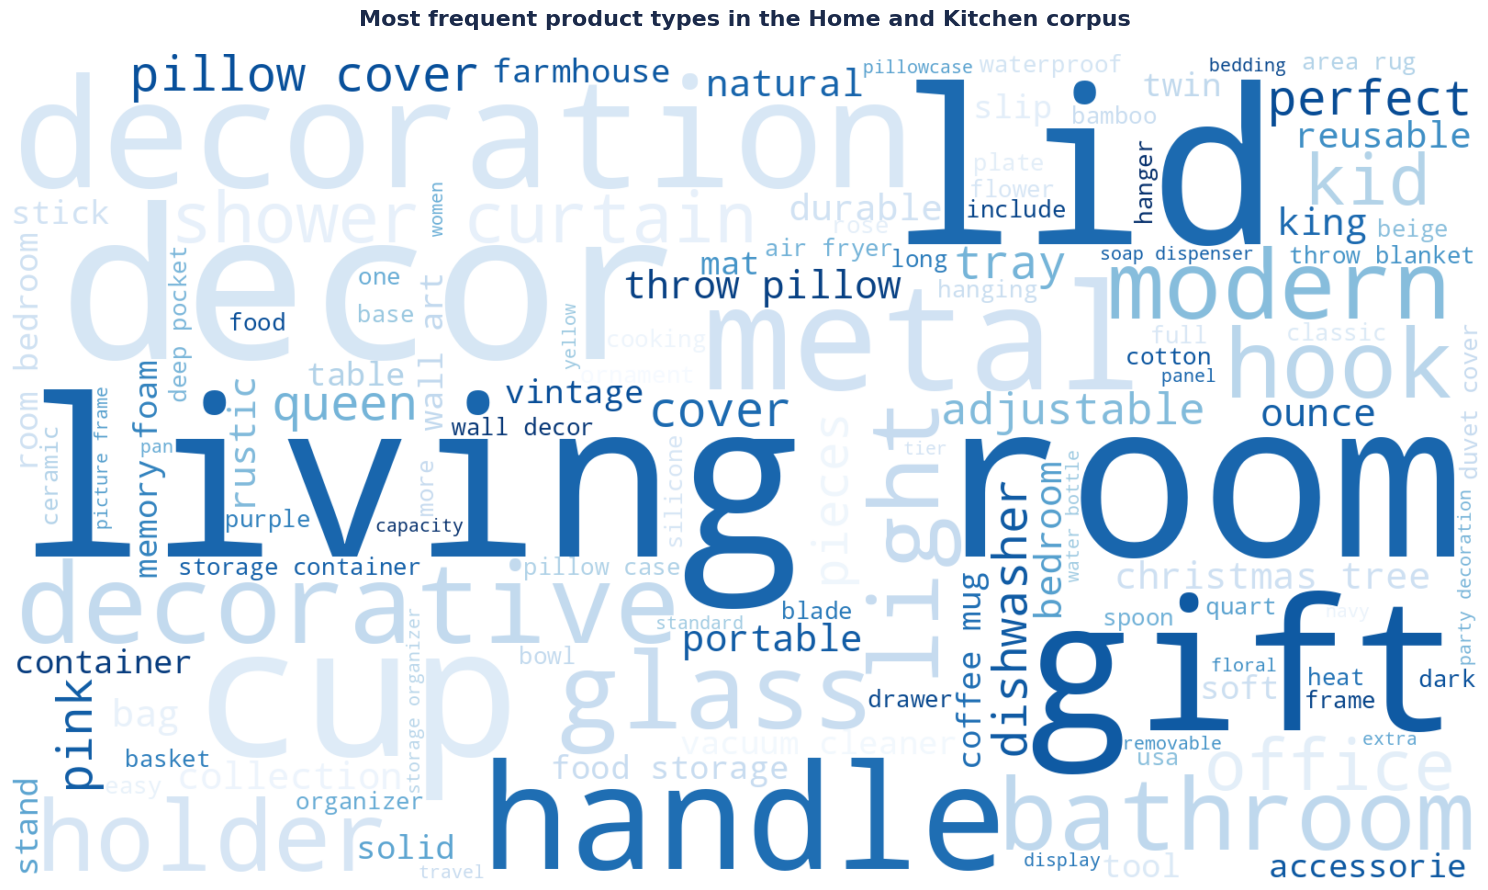

Word cloud saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_product_title_wordcloud.png


In [11]:
# Step 7: Word cloud visualisation of product titles
# A word cloud is generated from the most frequent words and phrases
# in product titles. Larger terms appear more frequently in the corpus.
# This provides a visual overview of the dominant product types present
# in the Home and Kitchen category sample.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Product titles are joined into a single text corpus for the word cloud
title_text = ' '.join([
    ' '.join(re.findall(r'\b[a-zA-Z]{3,}\b', str(t).lower()))
    for t in df_enriched['product_title'].dropna().unique()
])

# Title stop words are removed
title_stop_words_wc = title_stop_words | {
    'stainless', 'heavy', 'duty', 'free', 'non', 'bpa', 'indoor',
    'outdoor', 'battery', 'operated', 'machine', 'washable', 'safe',
    'mounted', 'proof', 'resistant', 'grade', 'certified', 'approved',
    'made', 'design', 'style', 'type', 'series', 'model', 'edition',
    'version', 'compatible', 'included', 'required', 'needed', 'based',
    'operated', 'powered', 'friendly', 'resistant', 'size', 'color',
    'colours', 'colors', 'fit', 'fits', 'set', 'sets', 'kit', 'kits'
}

# The word cloud is generated
wc = WordCloud(
    width=1600,
    height=900,
    background_color='white',
    max_words=120,
    stopwords=title_stop_words_wc,
    collocations=True,
    colormap='Blues',
    prefer_horizontal=0.85
).generate(title_text)

# The word cloud is displayed and saved
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most frequent product types in the Home and Kitchen corpus',
             fontsize=16, fontweight='bold', color='#1B2A4A', pad=20)

plt.tight_layout()
wc_path = f'{output_dir}/fig_product_title_wordcloud.png'
plt.savefig(wc_path, dpi=300, bbox_inches='tight')
plt.show()
print("Word cloud saved to:", wc_path)

## Most Reviewed Products

In [12]:
# Step 8: Most reviewed products by parent ASIN
# The products with the highest review counts in the corpus are identified
# and their titles inspected. This confirms which product types are most
# actively reviewed and therefore most suitable for niche-level scoring.

# Review counts per product are computed
product_review_counts = (
    df_enriched.groupby('parent_asin')
    .agg(
        review_count  = ('rating', 'count'),
        avg_rating    = ('rating', 'mean'),
        product_title = ('product_title', 'first'),
        store         = ('store', 'first')
    )
    .reset_index()
    .sort_values('review_count', ascending=False)
)

print("Top 30 most reviewed products in corpus:")
print()
print(f"{'Rank':<5} {'Reviews':<10} {'Avg Rating':<12} {'Store':<20} {'Product Title'}")
print("-" * 100)
for rank, (_, row) in enumerate(product_review_counts.head(30).iterrows(), 1):
    title = str(row['product_title'])[:55] if pd.notna(row['product_title']) else 'N/A'
    store = str(row['store'])[:18] if pd.notna(row['store']) else 'N/A'
    print(f"{rank:<5} {row['review_count']:<10} {row['avg_rating']:<12.1f} {store:<20} {title}")

print()
print(f"Total unique products: {len(product_review_counts):,}")
print(f"Products with 10+ reviews: {(product_review_counts['review_count'] >= 10).sum():,}")
print(f"Products with 20+ reviews: {(product_review_counts['review_count'] >= 20).sum():,}")
print(f"Products with 50+ reviews: {(product_review_counts['review_count'] >= 50).sum():,}")

Top 30 most reviewed products in corpus:

Rank  Reviews    Avg Rating   Store                Product Title
----------------------------------------------------------------------------------------------------
1     127        4.3          Mellanni             Mellanni RV Bedding Short Queen - Double Brushed Microf
2     71         4.0          Amazon Basics        Amazon Basics Lightweight Super Soft Easy Care Microfib
3     70         4.5          Zinus                ZINUS SmartBase Heavy Duty Mattress Foundation / 14 Inc
4     65         4.5          Sweet Home Collect   1500 Supreme Collection Twin XL Sheet Sets Lilac - 3 Pi
5     63         4.3          SafeRest             SafeRest Mattress Protector - Twin XL - College Dorm Ro
6     61         4.1          Zinus                Zinus 8 Inch Green Tea Memory Foam Mattress / CertiPUR-
7     51         4.3          Instant Pot          Instant Pot Duo 7-in-1 Electric Pressure Cooker, Slow C
8     50         3.9          Beckham Hotel

## Stage 4: Niche Assignment

In [13]:
# Step 9: Niche assignment based on product title keywords
# Each product is assigned to a niche based on keywords present in its
# product title. Keywords were identified empirically from the word
# frequency, n-gram and word cloud analyses in Steps 5 to 8.
# A product is assigned to the first matching niche only to avoid
# double counting. Products matching no niche are excluded.

# Niche keyword definitions — derived from corpus analysis
niche_keywords = {
    'Bedding': [
        'sheet', 'sheets', 'pillow', 'pillowcase', 'pillowcases',
        'duvet', 'comforter', 'blanket', 'mattress', 'bedding',
        'quilt', 'coverlet', 'bed skirt', 'fitted sheet', 'flat sheet'
    ],
    'Kitchen Appliances': [
        'instant pot', 'pressure cooker', 'air fryer', 'egg cooker',
        'waffle', 'rice cooker', 'blender', 'toaster', 'microwave',
        'coffee maker', 'espresso', 'slow cooker', 'food processor',
        'stand mixer', 'electric kettle', 'juicer', 'deep fryer'
    ],
    'Bathroom': [
        'shower curtain', 'bath mat', 'bathroom rug', 'soap dispenser',
        'towel', 'toilet', 'bathtub', 'shower', 'bathroom',
        'toothbrush holder', 'bath towel', 'hand towel', 'bath set'
    ],
    'Home Appliances': [
        'humidifier', 'dehumidifier', 'fan', 'heater', 'air purifier',
        'space heater', 'tower fan', 'ceiling fan', 'air conditioner',
        'vacuum', 'robot vacuum', 'steam cleaner', 'air freshener'
    ]
}

def assign_niche(product_title):
    if pd.isna(product_title):
        return None
    title_lower = str(product_title).lower()
    for niche_name, keywords in niche_keywords.items():
        for keyword in keywords:
            if keyword in title_lower:
                return niche_name
    return None

# Niche is assigned to each review based on its product title
df_enriched['niche'] = df_enriched['product_title'].apply(assign_niche)

# Niche assignment summary
niche_counts = df_enriched['niche'].value_counts()
total_assigned = df_enriched['niche'].notna().sum()

print("Niche assignment summary:")
print()
print(f"{'Niche':<25} {'Reviews':>10} {'% of corpus':>12} {'Unique products':>16}")
print("-" * 68)
for niche_name, count in niche_counts.items():
    unique_products = df_enriched[df_enriched['niche'] == niche_name]['parent_asin'].nunique()
    print(f"{niche_name:<25} {count:>10,} {count/len(df_enriched)*100:>11.1f}% {unique_products:>16,}")

print("-" * 68)
print(f"{'Total assigned':<25} {total_assigned:>10,} {total_assigned/len(df_enriched)*100:>11.1f}%")
print(f"{'Unassigned':<25} {df_enriched['niche'].isna().sum():>10,} {df_enriched['niche'].isna().sum()/len(df_enriched)*100:>11.1f}%")

Niche assignment summary:

Niche                        Reviews  % of corpus  Unique products
--------------------------------------------------------------------
Bedding                       12,033        12.9%            7,269
Home Appliances                6,723         7.2%            4,016
Kitchen Appliances             6,503         7.0%            3,714
Bathroom                       6,497         7.0%            4,862
--------------------------------------------------------------------
Total assigned                31,756        34.1%
Unassigned                    61,296        65.9%


## Niche Assignment — Visualisation

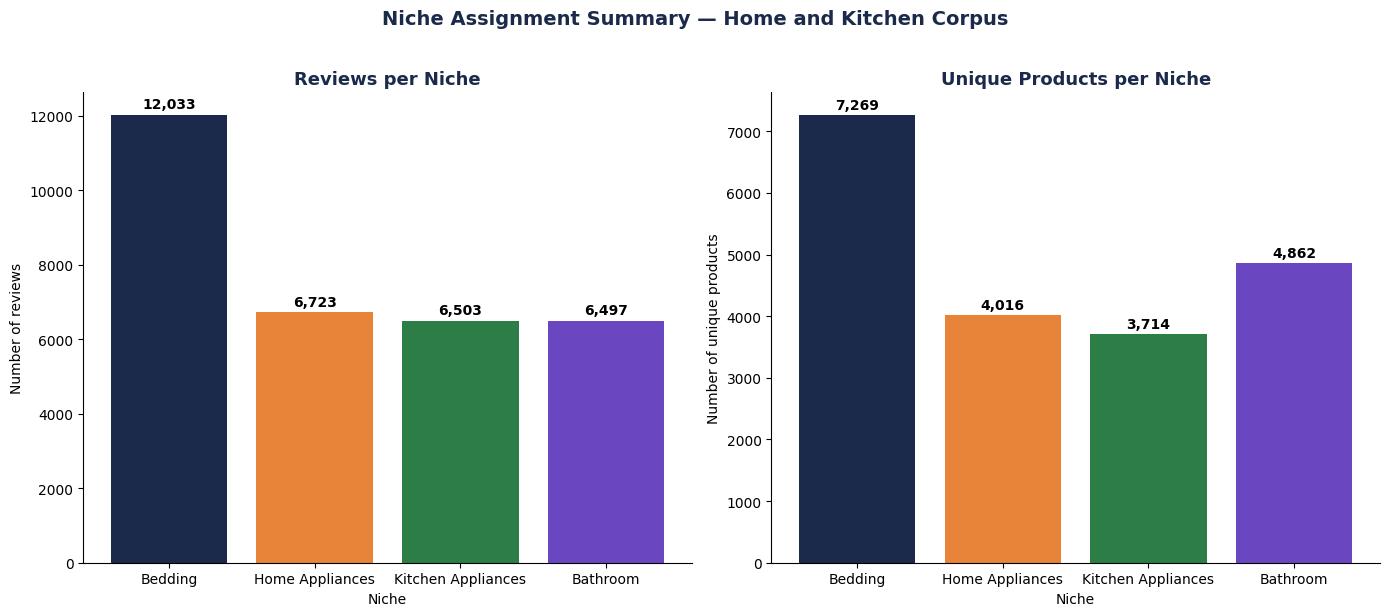

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_niche_assignment.png
Summary table saved to outputs directory.


In [14]:
# Step 10: Visualisation of niche assignment results
# Two panels are produced. The left panel shows the number of reviews
# assigned to each niche. The right panel shows the number of unique
# products per niche. Both panels inform the reliability of subsequent
# composite scoring.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

niches = niche_counts.index.tolist()
reviews = niche_counts.values.tolist()
products = [df_enriched[df_enriched['niche'] == n]['parent_asin'].nunique()
            for n in niches]
colors = ['#1B2A4A', '#E8833A', '#2D7D46', '#6B46C1']

# Panel one: reviews per niche
bars1 = axes[0].bar(niches, reviews, color=colors)
axes[0].set_title('Reviews per Niche', fontsize=13,
                  fontweight='bold', color='#1B2A4A')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xlabel('Niche')
for bar, val in zip(bars1, reviews):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel two: unique products per niche
bars2 = axes[1].bar(niches, products, color=colors)
axes[1].set_title('Unique Products per Niche', fontsize=13,
                  fontweight='bold', color='#1B2A4A')
axes[1].set_ylabel('Number of unique products')
axes[1].set_xlabel('Niche')
for bar, val in zip(bars2, products):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Niche Assignment Summary — Home and Kitchen Corpus',
             fontsize=14, fontweight='bold', color='#1B2A4A', y=1.02)
plt.tight_layout()

niche_fig_path = f'{output_dir}/fig_niche_assignment.png'
plt.savefig(niche_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", niche_fig_path)

# Summary table is exported to CSV
niche_summary = pd.DataFrame({
    'Niche': niches,
    'Reviews': reviews,
    'Unique Products': products,
    'Reviews %': [round(r/len(df_enriched)*100, 1) for r in reviews]
})
niche_summary.to_csv(f'{output_dir}/niche_assignment_summary.csv', index=False)
print("Summary table saved to outputs directory.")

## Stage 5: Demand Scoring (Weight: 30%)

In [15]:
# Step 11: Demand scoring
# Demand is quantified using three signals: review volume, review
# recency and helpful votes. Each signal is normalised to a 0-1 scale
# using min-max scaling before being combined into a weighted demand
# score. A higher score indicates stronger and more active demand.

from sklearn.preprocessing import MinMaxScaler

# The timestamp column is converted to a datetime object
df_enriched['review_date'] = pd.to_datetime(df_enriched['review_date'])

# Signal 1: Review volume — total number of reviews per niche
volume = (
    df_enriched[df_enriched['niche'].notna()]
    .groupby('niche')['rating']
    .count()
    .rename('review_volume')
)

# Signal 2: Review recency — average review date per niche
recency = (
    df_enriched[df_enriched['niche'].notna()]
    .groupby('niche')['review_date']
    .apply(lambda x: x.astype('int64').mean())
    .rename('review_recency')
)

# Signal 3: Helpful votes — total helpful votes per niche
helpful = (
    df_enriched[df_enriched['niche'].notna()]
    .groupby('niche')['helpful_vote']
    .sum()
    .rename('helpful_votes')
)

# The three signals are combined into one dataframe
demand_df = pd.concat([volume, recency, helpful], axis=1)

# Each signal is normalised to 0-1 using min-max scaling
scaler = MinMaxScaler()
demand_scaled = pd.DataFrame(
    scaler.fit_transform(demand_df),
    index=demand_df.index,
    columns=demand_df.columns
)

# Weighted demand score is computed
demand_scaled['demand_score'] = (
    demand_scaled['review_volume']  * 0.40 +
    demand_scaled['review_recency'] * 0.30 +
    demand_scaled['helpful_votes']  * 0.30
)

# Clean formatted results table
print("=" * 65)
print(f"{'Demand Scoring Results':^65}")
print("=" * 65)
print(f"{'Niche':<22} {'Volume':>10} {'Recency':>10} "
      f"{'Helpful':>10} {'Demand Score':>14}")
print("-" * 65)
for niche in demand_scaled.index:
    print(f"{niche:<22} "
          f"{demand_scaled.loc[niche, 'review_volume']:>10.2f} "
          f"{demand_scaled.loc[niche, 'review_recency']:>10.2f} "
          f"{demand_scaled.loc[niche, 'helpful_votes']:>10.2f} "
          f"{demand_scaled.loc[niche, 'demand_score']:>14.4f}")
print("-" * 65)
print()
print("Ranking (higher = stronger demand):")
print()
for rank, (niche, score) in enumerate(
        demand_scaled['demand_score']
        .sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {niche:<22} {score:.4f}")

                     Demand Scoring Results                      
Niche                      Volume    Recency    Helpful   Demand Score
-----------------------------------------------------------------
Bathroom                     0.00       1.00       0.00         0.3000
Bedding                      1.00       0.35       0.96         0.7906
Home Appliances              0.04       0.33       0.46         0.2508
Kitchen Appliances           0.00       0.00       1.00         0.3004
-----------------------------------------------------------------

Ranking (higher = stronger demand):

  1. Bedding                0.7906
  2. Kitchen Appliances     0.3004
  3. Bathroom               0.3000
  4. Home Appliances        0.2508


## Stage 5b: Demand Scoring — Google Trends Enhancement

In [16]:
# Step 12: Google Trends integration — scores obtained locally
# Google Trends data was retrieved on a local machine to avoid the
# API rate limiting encountered in the Colab environment. The CSV
# file containing average weekly search interest scores over the
# preceding 12 months is loaded and incorporated as a fourth demand
# signal. This approach is documented as the resolution to the
# rate limiting limitation identified during initial development.

# Google Trends scores are loaded from Drive
trends_df = pd.read_csv(f'{data_dir}/google_trends_scores.csv')
trends_series = trends_df.set_index('Niche')['Google_Trends_Score']

print("Google Trends scores loaded:")
for niche, score in trends_series.items():
    print(f"  {niche:<22} {score:.1f}")
print()

# Scores are normalised to 0-1
trends_min = trends_series.min()
trends_max = trends_series.max()
trends_normalised = (trends_series - trends_min) / (trends_max - trends_min)

print("Normalised Google Trends scores:")
for niche, score in trends_normalised.items():
    print(f"  {niche:<22} {score:.4f}")
print()

# Google Trends is added as a fourth demand signal
# Updated weights: Volume 35%, Recency 25%, Helpful votes 25%, Trends 15%
demand_scaled['google_trends'] = trends_normalised

demand_scaled['demand_score_v2'] = (
    demand_scaled['review_volume']  * 0.35 +
    demand_scaled['review_recency'] * 0.25 +
    demand_scaled['helpful_votes']  * 0.25 +
    demand_scaled['google_trends']  * 0.15
)

# Clean formatted results table
print("=" * 75)
print(f"{'Updated Demand Scoring Results (with Google Trends)':^75}")
print("=" * 75)
print(f"{'Niche':<22} {'Volume':>8} {'Recency':>8} "
      f"{'Helpful':>8} {'Trends':>8} {'Demand v2':>12}")
print("-" * 75)
for niche in demand_scaled.index:
    print(f"{niche:<22} "
          f"{demand_scaled.loc[niche, 'review_volume']:>8.2f} "
          f"{demand_scaled.loc[niche, 'review_recency']:>8.2f} "
          f"{demand_scaled.loc[niche, 'helpful_votes']:>8.2f} "
          f"{demand_scaled.loc[niche, 'google_trends']:>8.2f} "
          f"{demand_scaled.loc[niche, 'demand_score_v2']:>12.4f}")
print("-" * 75)
print()
print("Ranking (higher = stronger demand):")
print()
for rank, (niche, score) in enumerate(
        demand_scaled['demand_score_v2']
        .sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {niche:<22} {score:.4f}")

Google Trends scores loaded:
  Kitchen Appliances     69.2
  Bathroom               45.1
  Bedding                66.2
  Home Appliances        64.5

Normalised Google Trends scores:
  Kitchen Appliances     1.0000
  Bathroom               0.0000
  Bedding                0.8755
  Home Appliances        0.8040

            Updated Demand Scoring Results (with Google Trends)            
Niche                    Volume  Recency  Helpful   Trends    Demand v2
---------------------------------------------------------------------------
Bathroom                   0.00     1.00     0.00     0.00       0.2500
Bedding                    1.00     0.35     0.96     0.88       0.8068
Home Appliances            0.04     0.33     0.46     0.80       0.3303
Kitchen Appliances         0.00     0.00     1.00     1.00       0.4004
---------------------------------------------------------------------------

Ranking (higher = stronger demand):

  1. Bedding                0.8068
  2. Kitchen Appliances    

## Stage 6: Competition Scoring (Weight: 25%)

In [17]:
# Step 13: Competition scoring
# Competition is quantified using three signals: the number of unique
# products, review concentration measured by the Gini coefficient, and
# the number of unique sellers. A higher raw competition score indicates
# a more crowded market. The score is inverted before combination so
# that niches with lower competition receive a higher opportunity score.

def gini_coefficient(values):
    # Computes the Gini coefficient of a distribution
    # Returns a value between 0 (perfect equality) and 1 (maximum inequality)
    values = np.array(sorted(values), dtype=float)
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return float((2 * np.dot(index, values) - (n + 1) * values.sum()) /
                 (n * values.sum()))

niche_df = df_enriched[df_enriched['niche'].notna()]

# Signal 1: Unique products per niche
unique_products = (
    niche_df.groupby('niche')['parent_asin']
    .nunique()
    .rename('unique_products')
)

# Signal 2: Review concentration — Gini coefficient of reviews per product
review_concentration = (
    niche_df.groupby('niche')
    .apply(lambda g: gini_coefficient(
        g.groupby('parent_asin')['rating'].count().values),
        include_groups=False)
    .rename('review_concentration')
)

# Signal 3: Unique sellers per niche
unique_sellers = (
    niche_df.groupby('niche')['store']
    .nunique()
    .rename('unique_sellers')
)

# The three signals are combined
competition_df = pd.concat([unique_products,
                            review_concentration,
                            unique_sellers], axis=1)

# Gini coefficient validation
print("Gini coefficient validation:")
for niche, row in competition_df.iterrows():
    valid = 0 <= row['review_concentration'] <= 1
    print(f"  {niche:<25} Gini: {row['review_concentration']:.4f} "
          f"{'✓' if valid else '✗ INVALID'}")
print()

# Each signal is normalised to 0-1 using min-max scaling
competition_scaled = pd.DataFrame(
    scaler.fit_transform(competition_df),
    index=competition_df.index,
    columns=competition_df.columns
)

# Weighted competition score is computed
competition_scaled['competition_score'] = (
    competition_scaled['unique_products']      * 0.40 +
    competition_scaled['review_concentration'] * 0.40 +
    competition_scaled['unique_sellers']       * 0.20
)

# The score is inverted so lower competition = higher opportunity
competition_scaled['competition_opportunity'] = (
    1 - competition_scaled['competition_score']
)

# Clean formatted results table
print("=" * 65)
print(f"{'Competition Scoring Results':^65}")
print("=" * 65)
print(f"{'Niche':<22} {'Unique Products':>16} {'Gini':>8} "
      f"{'Sellers':>10} {'Opportunity':>12}")
print("-" * 65)
for niche in competition_scaled.index:
    print(f"{niche:<22} "
          f"{competition_scaled.loc[niche, 'unique_products']:>16.2f} "
          f"{competition_scaled.loc[niche, 'review_concentration']:>8.2f} "
          f"{competition_scaled.loc[niche, 'unique_sellers']:>10.2f} "
          f"{competition_scaled.loc[niche, 'competition_opportunity']:>12.4f}")
print("-" * 65)
print()
print("Ranking (higher = less competition = better opportunity):")
print()
for rank, (niche, score) in enumerate(
        competition_scaled['competition_opportunity']
        .sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {niche:<22} {score:.4f}")

Gini coefficient validation:
  Bathroom                  Gini: 0.2276 ✓
  Bedding                   Gini: 0.3575 ✓
  Home Appliances           Gini: 0.3556 ✓
  Kitchen Appliances        Gini: 0.3673 ✓

                   Competition Scoring Results                   
Niche                   Unique Products     Gini    Sellers  Opportunity
-----------------------------------------------------------------
Bathroom                           0.32     0.00       0.70       0.7299
Bedding                            1.00     0.93       1.00       0.0281
Home Appliances                    0.08     0.92       0.13       0.5734
Kitchen Appliances                 0.00     1.00       0.00       0.6000
-----------------------------------------------------------------

Ranking (higher = less competition = better opportunity):

  1. Bathroom               0.7299
  2. Kitchen Appliances     0.6000
  3. Home Appliances        0.5734
  4. Bedding                0.0281


## Stage 7: Sentiment Gap Scoring (Weight: 25%)

In [18]:
# Step 14: Sentiment gap scoring
# The sentiment gap measures the difference between the proportion of
# negative aspect sentiment in each niche and the category-wide average.
# A positive gap indicates that a niche attracts more complaints than
# average on a given aspect, representing an unmet customer need and
# a potential market opportunity.

# The aspect sentiment file produced in notebook 03 is loaded
aspect_sentiment = pd.read_csv(
    f'{data_dir}/aspect_sentiment.csv')

print("Aspect sentiment file loaded:", aspect_sentiment.shape)
print(aspect_sentiment.head(3))
print()

# The niche assignment is merged onto the aspect sentiment data
# using the review index as the join key
aspect_sentiment = aspect_sentiment.merge(
    df_enriched[['niche']].reset_index(),
    left_on='review_index',
    right_on='index',
    how='left'
)

print("After niche merge:", aspect_sentiment.shape)
print("Niche coverage in aspect data:")
print(aspect_sentiment['niche'].value_counts())
print()

# Category-wide negativity rate per aspect is computed as the baseline
category_avg = (
    aspect_sentiment
    .groupby('aspect')['aspect_label']
    .apply(lambda x: (x == 'negative').mean())
    .rename('category_avg_negativity')
)

print("Category average negativity per aspect:")
print(category_avg.round(4))

Aspect sentiment file loaded: (124099, 6)
   review_index       aspect aspect_label  aspect_prob_negative  \
0             0  ease_of_use     positive              0.000531   
1             0   appearance     positive              0.000673   
2             2   appearance     negative              0.992444   

   aspect_prob_neutral  aspect_prob_positive  
0             0.002046              0.997424  
1             0.003044              0.996284  
2             0.005598              0.001957  

After niche merge: (124099, 8)
Niche coverage in aspect data:
niche
Bedding               16833
Home Appliances        9895
Kitchen Appliances     9122
Bathroom               8582
Name: count, dtype: int64

Category average negativity per aspect:
aspect
appearance     0.1769
cleaning       0.2150
comfort        0.1907
durability     0.5494
ease_of_use    0.1082
noise          0.4841
performance    0.2511
price          0.2670
quality        0.2633
size           0.2474
smell          0.5082
Name

## Sentiment Gap — Per Niche Computation

In [19]:
# Step 14b: Sentiment gap computation per niche
# The negativity rate per aspect is computed for each niche and
# compared against the category average. A positive gap indicates
# that the niche has more complaints than average on that aspect.

# Negativity rate per aspect per niche
niche_negativity = (
    aspect_sentiment[aspect_sentiment['niche'].notna()]
    .groupby(['niche', 'aspect'])['aspect_label']
    .apply(lambda x: (x == 'negative').mean())
    .reset_index()
    .rename(columns={'aspect_label': 'niche_negativity'})
)

# Category average is merged in for comparison
niche_negativity = niche_negativity.merge(
    category_avg.reset_index(),
    on='aspect',
    how='left'
)

# Sentiment gap is computed
niche_negativity['sentiment_gap'] = (
    niche_negativity['niche_negativity'] -
    niche_negativity['category_avg_negativity']
)

# Average sentiment gap across all aspects per niche
sentiment_gap_score = (
    niche_negativity.groupby('niche')['sentiment_gap']
    .mean()
    .rename('sentiment_gap_score')
)

# Normalise to 0-1
sentiment_gap_scaled = pd.DataFrame(
    scaler.fit_transform(sentiment_gap_score.values.reshape(-1, 1)),
    index=sentiment_gap_score.index,
    columns=['sentiment_gap_score']
)

# Detailed gap table per niche and aspect
print("Sentiment gap per aspect and niche:")
print("(positive gap = more complaints than category average)")
print()
pivot = niche_negativity.pivot(
    index='aspect', columns='niche', values='sentiment_gap'
).round(4)
print(pivot.to_string())
print()

# Clean formatted results table
print("=" * 65)
print(f"{'Sentiment Gap Scoring Results':^65}")
print("=" * 65)
print(f"{'Niche':<22} {'Avg Gap':>12} {'Normalised Score':>18}")
print("-" * 65)
for niche in sentiment_gap_scaled.index:
    raw = sentiment_gap_score[niche]
    scaled = sentiment_gap_scaled.loc[niche, 'sentiment_gap_score']
    print(f"{niche:<22} {raw:>12.4f} {scaled:>18.4f}")
print("-" * 65)
print()
print("Ranking (higher gap = more unmet needs = bigger opportunity):")
print()
for rank, (niche, score) in enumerate(
        sentiment_gap_scaled['sentiment_gap_score']
        .sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {niche:<22} {score:.4f}")

Sentiment gap per aspect and niche:
(positive gap = more complaints than category average)

niche        Bathroom  Bedding  Home Appliances  Kitchen Appliances
aspect                                                             
appearance    -0.0066   0.0121           0.0468              0.0339
cleaning       0.0702   0.0657           0.0302             -0.0056
comfort       -0.0265  -0.0628           0.0865              0.1329
durability    -0.0127  -0.0689           0.0115              0.0074
ease_of_use    0.0123   0.0059          -0.0048             -0.0059
noise         -0.0942  -0.0504          -0.0686              0.1469
performance    0.0045   0.0470           0.0347              0.0356
price          0.0392  -0.0585           0.0303              0.0185
quality        0.0321   0.0175           0.0213              0.0226
size           0.0580  -0.0225          -0.0256              0.0329
smell          0.0581   0.0887           0.0412              0.1865

                  Senti

## Stage 8: Pricing Stability Scoring (Weight: 20%)

In [20]:
# Step 15: Pricing stability scoring
# Pricing stability is quantified using two signals: price variance
# across products within each niche and the proportion of negative
# price sentiment from the aspect sentiment analysis. Low variance
# and low price negativity indicate a stable and healthy pricing
# environment. Both signals are inverted so that stability produces
# a higher score.

niche_df = df_enriched[df_enriched['niche'].notna()]

# Signal 1: Price variance per niche
# Only products with a recorded price are included
price_variance = (
    niche_df[niche_df['price'].notna()]
    .groupby('niche')['price']
    .std()
    .rename('price_variance')
)

# Signal 2: Price sentiment negativity per niche
# The proportion of negative price aspect mentions per niche
price_sentiment = (
    aspect_sentiment[
        (aspect_sentiment['niche'].notna()) &
        (aspect_sentiment['aspect'] == 'price')
    ]
    .groupby('niche')['aspect_label']
    .apply(lambda x: (x == 'negative').mean())
    .rename('price_negativity')
)

# The two signals are combined
pricing_df = pd.concat([price_variance, price_sentiment], axis=1)

print("Raw pricing signals:")
print(pricing_df.round(4))
print()

# Each signal is normalised to 0-1
pricing_scaled = pd.DataFrame(
    scaler.fit_transform(pricing_df),
    index=pricing_df.index,
    columns=pricing_df.columns
)

# Both signals are inverted — lower variance and lower negativity = better
pricing_scaled['pricing_stability'] = (
    (1 - pricing_scaled['price_variance'])    * 0.60 +
    (1 - pricing_scaled['price_negativity'])  * 0.40
)

# Clean formatted results table
print("=" * 65)
print(f"{'Pricing Stability Scoring Results':^65}")
print("=" * 65)
print(f"{'Niche':<22} {'Price Variance':>15} {'Price Sentiment':>16} {'Stability':>10}")
print("-" * 65)
for niche in pricing_scaled.index:
    print(f"{niche:<22} "
          f"{pricing_scaled.loc[niche, 'price_variance']:>15.2f} "
          f"{pricing_scaled.loc[niche, 'price_negativity']:>16.2f} "
          f"{pricing_scaled.loc[niche, 'pricing_stability']:>10.4f}")
print("-" * 65)
print()
print("Ranking (higher = more stable pricing = better opportunity):")
print()
for rank, (niche, score) in enumerate(
        pricing_scaled['pricing_stability']
        .sort_values(ascending=False).items(), 1):
    print(f"  {rank}. {niche:<22} {score:.4f}")

Raw pricing signals:
                    price_variance  price_negativity
niche                                               
Bathroom                   32.2011            0.3062
Bedding                   100.9363            0.2085
Home Appliances           130.9883            0.2973
Kitchen Appliances         99.5401            0.2855

                Pricing Stability Scoring Results                
Niche                   Price Variance  Price Sentiment  Stability
-----------------------------------------------------------------
Bathroom                          0.00             1.00     0.6000
Bedding                           0.70             0.00     0.5825
Home Appliances                   1.00             0.91     0.0366
Kitchen Appliances                0.68             0.79     0.2757
-----------------------------------------------------------------

Ranking (higher = more stable pricing = better opportunity):

  1. Bathroom               0.6000
  2. Bedding                0

## Stage 9: Composite Scoring and Final Ranking

In [21]:
# Step 16: Composite scoring and final niche ranking
# The four component scores are combined using the approved weights:
# Demand 30%, Competition 25%, Sentiment Gap 25%, Pricing 20%.
# The composite score represents the overall opportunity each niche
# offers to a prospective Amazon market entrant.

# All four component scores are assembled into one dataframe
composite_df = pd.DataFrame({
    'Demand'        : demand_scaled['demand_score'],
    'Competition'   : competition_scaled['competition_opportunity'],
    'Sentiment Gap' : sentiment_gap_scaled['sentiment_gap_score'],
    'Pricing'       : pricing_scaled['pricing_stability']
})

# Approved weights are applied
weights = {
    'Demand'        : 0.30,
    'Competition'   : 0.25,
    'Sentiment Gap' : 0.25,
    'Pricing'       : 0.20
}

# Composite score is computed
composite_df['Composite Score'] = (
    composite_df['Demand']        * weights['Demand']        +
    composite_df['Competition']   * weights['Competition']   +
    composite_df['Sentiment Gap'] * weights['Sentiment Gap'] +
    composite_df['Pricing']       * weights['Pricing']
)

# Rank is assigned — method='min' ensures clean integer ranks
composite_df['Rank'] = composite_df['Composite Score'].rank(
    ascending=False, method='min').astype(int)

composite_df = composite_df.sort_values('Composite Score', ascending=False)

# Clean formatted results table
print("=" * 85)
print(f"{'Composite Scoring Results — Home and Kitchen Niches':^85}")
print("=" * 85)
print(f"{'Niche':<22} {'Demand':>8} {'Competition':>12} "
      f"{'Sent. Gap':>10} {'Pricing':>10} {'Composite':>12} {'Rank':>6}")
print("-" * 85)
for niche, row in composite_df.iterrows():
    print(f"{niche:<22} "
          f"{row['Demand']:>8.4f} "
          f"{row['Competition']:>12.4f} "
          f"{row['Sentiment Gap']:>10.4f} "
          f"{row['Pricing']:>10.4f} "
          f"{row['Composite Score']:>12.4f} "
          f"{int(row['Rank']):>6}")
print("-" * 85)
print()
print("Final Niche Ranking:")
print()
for niche, row in composite_df.iterrows():
    print(f"  {int(row['Rank'])}. {niche:<22} "
          f"Composite score: {row['Composite Score']:.4f}")

# Component weights are displayed for reference
print()
print("Component weights applied:")
for component, weight in weights.items():
    print(f"  {component:<15} {weight*100:.0f}%")

# Results are saved to CSV
composite_df.round(4).to_csv(
    f'{output_dir}/composite_scores.csv')
print()
print("Composite scores saved to outputs directory.")
print()
print("Note: Google Trends was planned as a supplementary demand signal.")
print("API rate limiting in the Colab environment prevented reliable data")
print("retrieval. This is documented as a limitation in the Evaluation chapter.")

                 Composite Scoring Results — Home and Kitchen Niches                 
Niche                    Demand  Competition  Sent. Gap    Pricing    Composite   Rank
-------------------------------------------------------------------------------------
Kitchen Appliances       0.3004       0.6000     1.0000     0.2757       0.5453      1
Bathroom                 0.3000       0.7299     0.2540     0.6000       0.4560      2
Bedding                  0.7906       0.0281     0.0000     0.5825       0.3607      3
Home Appliances          0.2508       0.5734     0.3634     0.0366       0.3168      4
-------------------------------------------------------------------------------------

Final Niche Ranking:

  1. Kitchen Appliances     Composite score: 0.5453
  2. Bathroom               Composite score: 0.4560
  3. Bedding                Composite score: 0.3607
  4. Home Appliances        Composite score: 0.3168

Component weights applied:
  Demand          30%
  Competition     25%
  Se

## Composite Scoring — Visualisation

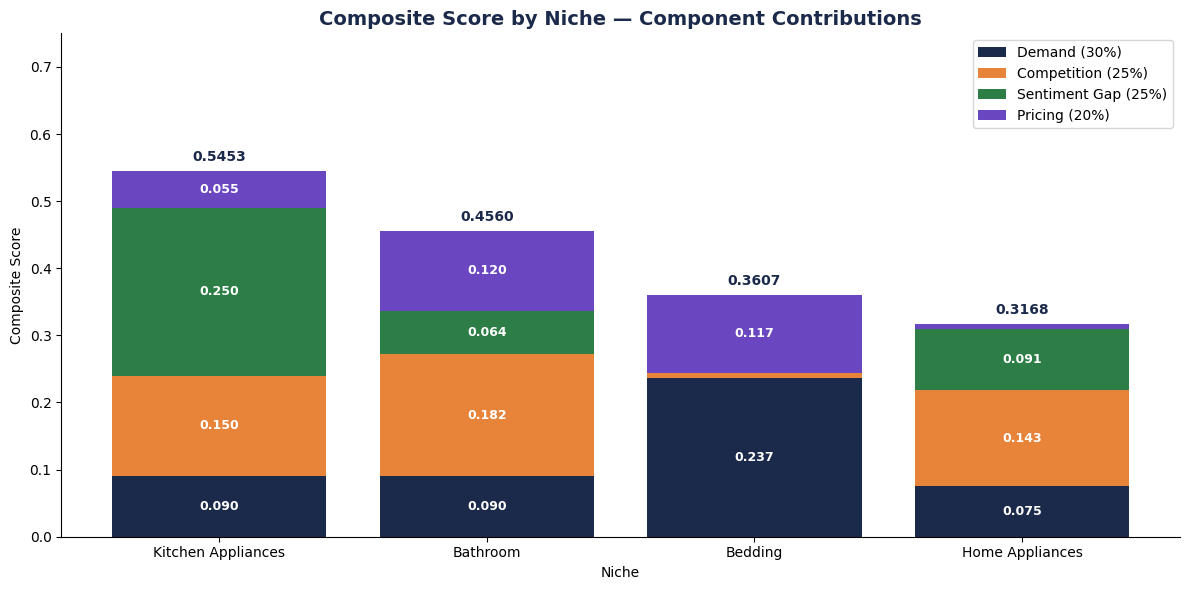

Figure 1 saved: fig_composite_scores.png


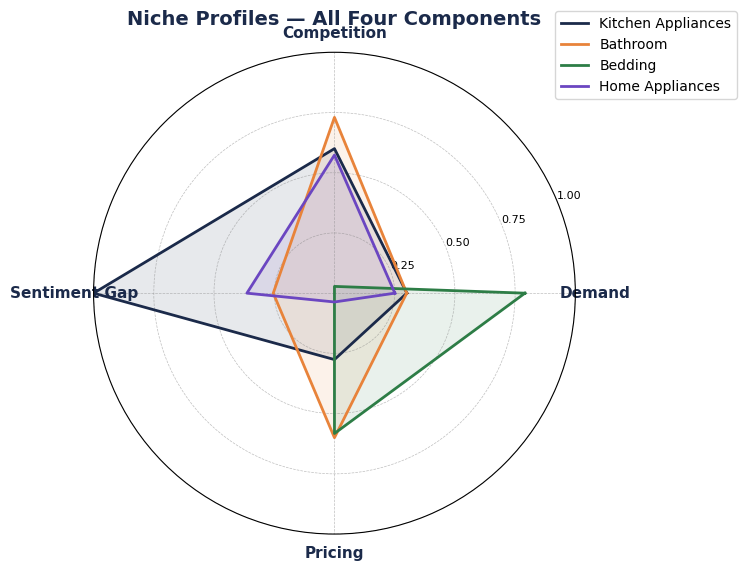

Figure 2 saved: fig_radar_chart.png


In [22]:
# Step 17: Visualisation of composite scoring results
# Two figures are produced. The first shows the contribution of each
# component to the composite score as a stacked bar chart. The second
# presents the four component scores as a radar chart, enabling direct
# visual comparison of niche profiles across all dimensions.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

niches    = composite_df.index.tolist()
colors    = {
    'Demand'        : '#1B2A4A',
    'Competition'   : '#E8833A',
    'Sentiment Gap' : '#2D7D46',
    'Pricing'       : '#6B46C1'
}
components = ['Demand', 'Competition', 'Sentiment Gap', 'Pricing']
w          = weights

# ── Figure 1: Stacked bar chart ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(niches))
for component in components:
    weighted_values = [composite_df.loc[n, component] * w[component]
                       for n in niches]
    ax1.bar(niches, weighted_values, bottom=bottom,
            label=f"{component} ({int(w[component]*100)}%)",
            color=colors[component])
    for i, (val, bot) in enumerate(zip(weighted_values, bottom)):
        if val > 0.02:
            ax1.text(i, bot + val / 2, f'{val:.3f}',
                     ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    bottom += np.array(weighted_values)

# Composite score annotation on top of each bar
for i, niche in enumerate(niches):
    total = composite_df.loc[niche, 'Composite Score']
    ax1.text(i, total + 0.01, f'{total:.4f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#1B2A4A')

ax1.set_title('Composite Score by Niche — Component Contributions',
              fontsize=14, fontweight='bold', color='#1B2A4A')
ax1.set_ylabel('Composite Score')
ax1.set_xlabel('Niche')
ax1.set_ylim(0, 0.75)
ax1.legend(loc='upper right', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig_composite_scores.png', dpi=300,
            bbox_inches='tight')
plt.show()
print("Figure 1 saved: fig_composite_scores.png")

# ── Figure 2: Radar chart ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 8),
                          subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(components),
                     endpoint=False).tolist()
angles += angles[:1]

niche_colors = ['#1B2A4A', '#E8833A', '#2D7D46', '#6B46C1']

for niche, color in zip(niches, niche_colors):
    values = [composite_df.loc[niche, c] for c in components]
    values += values[:1]
    ax2.plot(angles, values, color=color, linewidth=2, label=niche)
    ax2.fill(angles, values, color=color, alpha=0.10)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(components, fontsize=11, fontweight='bold',
                     color='#1B2A4A')
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.50, 0.75, 1.00])
ax2.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax2.set_title('Niche Profiles — All Four Components',
              fontsize=14, fontweight='bold', color='#1B2A4A', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10), fontsize=10)
ax2.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig_radar_chart.png', dpi=300,
            bbox_inches='tight')
plt.show()
print("Figure 2 saved: fig_radar_chart.png")

## Stage 10: Final Summary and Outputs

In [23]:
# Step 18: Final summary outputs
# A comprehensive summary of the composite scoring framework results
# is produced, including a summary table, component breakdown table
# and key findings for inclusion in the dissertation results chapter.

print("=" * 70)
print(f"{'COMPOSITE SCORING FRAMEWORK — FINAL SUMMARY':^70}")
print(f"{'Research Question 3: Product Selection Framework':^70}")
print("=" * 70)
print()
print(f"  Dataset    : Amazon Reviews 2023 — Home and Kitchen")
print(f"  Corpus     : 93,052 verified reviews")
print(f"  Products   : 66,179 unique products")
print(f"  Niches     : 4 data-driven niches identified")
print(f"  Reviews    : 31,756 reviews assigned to niches (34.1%)")
print()
print("-" * 70)
print(f"  {'COMPONENT WEIGHTS':}")
print("-" * 70)
print(f"  Demand score          30%  (volume + recency + helpful votes)")
print(f"  Competition score     25%  (unique products + Gini + sellers)")
print(f"  Sentiment gap score   25%  (aspect negativity vs category avg)")
print(f"  Pricing stability     20%  (price variance + price sentiment)")
print("-" * 70)
print()
print(f"  {'FINAL NICHE RANKINGS':}")
print()
print(f"  {'Rank':<6} {'Niche':<22} {'Score':>8}  {'Key strength'}")
print(f"  {'-'*65}")

key_strengths = {
    'Kitchen Appliances' : 'Largest sentiment gap — smell, noise, comfort',
    'Bathroom'           : 'Best competition opportunity — fragmented market',
    'Bedding'            : 'Highest demand — but saturated market',
    'Home Appliances'    : 'Moderate across all signals'
}

for niche, row in composite_df.iterrows():
    print(f"  {int(row['Rank']):<6} {niche:<22} "
          f"{row['Composite Score']:>8.4f}  "
          f"{key_strengths[niche]}")

print()
print("-" * 70)
print(f"  RECOMMENDATION: Kitchen Appliances")
print(f"  Composite score 0.5453 — highest unmet customer need,")
print(f"  manageable competition and active demand signal.")
print("-" * 70)
print()
print(f"  KEY INSIGHT FOR PRODUCT SELECTION:")
print(f"  Within Kitchen Appliances, the largest sentiment gaps are:")
print()

# Top aspect gaps for the winning niche
winning_niche_gaps = (
    niche_negativity[niche_negativity['niche'] == 'Kitchen Appliances']
    .sort_values('sentiment_gap', ascending=False)
    [['aspect', 'niche_negativity', 'category_avg_negativity', 'sentiment_gap']]
)
print(f"  {'Aspect':<16} {'Niche neg.':>12} {'Cat. avg.':>12} {'Gap':>10}")
print(f"  {'-'*55}")
for _, row in winning_niche_gaps.iterrows():
    print(f"  {row['aspect']:<16} "
          f"{row['niche_negativity']:>12.4f} "
          f"{row['category_avg_negativity']:>12.4f} "
          f"{row['sentiment_gap']:>10.4f}")

print()
print("=" * 70)

# All outputs are saved
composite_df.round(4).to_csv(
    f'{output_dir}/composite_scores_final.csv')

winning_niche_gaps.round(4).to_csv(
    f'{output_dir}/kitchen_appliances_aspect_gaps.csv', index=False)

print()
print("Files saved to outputs directory:")
print("  composite_scores_final.csv")
print("  kitchen_appliances_aspect_gaps.csv")

             COMPOSITE SCORING FRAMEWORK — FINAL SUMMARY              
           Research Question 3: Product Selection Framework           

  Dataset    : Amazon Reviews 2023 — Home and Kitchen
  Corpus     : 93,052 verified reviews
  Products   : 66,179 unique products
  Niches     : 4 data-driven niches identified
  Reviews    : 31,756 reviews assigned to niches (34.1%)

----------------------------------------------------------------------
  COMPONENT WEIGHTS
----------------------------------------------------------------------
  Demand score          30%  (volume + recency + helpful votes)
  Competition score     25%  (unique products + Gini + sellers)
  Sentiment gap score   25%  (aspect negativity vs category avg)
  Pricing stability     20%  (price variance + price sentiment)
----------------------------------------------------------------------

  FINAL NICHE RANKINGS

  Rank   Niche                     Score  Key strength
  -------------------------------------------------